In [ ]:
import sys
sys.path.insert(0, "../../../")

import numpy as np
# import astropy.units as u
import matplotlib.pyplot as plt

from agnpy.photo_meson.kernels import eta_0, interpolate_g_parameter, gKernel

In [3]:
interp = interpolate_g_parameter("gamma","A4")

In [4]:
print(interp(1.2,140))
print(interp(1.2,150))
print((interp(1.2,140)+interp(1.2,150))/2)
print(interp(1.2,145))

-0.7656679370186489
-0.5775625318803882
-0.6716152344495185
-0.6716152344495185


In [5]:
dPhi = gKernel("gamma")

In [6]:
dPhi(30.,180.,1e-3)

array(1.5169891e-15)

In [7]:
dPhi(30.,[180.,160.],1e-3)

array([1.51698910e-15, 1.48908752e-15])

In [8]:
theta = np.linspace(0., 180., 18*4)
B = dPhi(30., theta, 1e-3)
print(B*theta)


[0.00000000e+000 0.00000000e+000 0.00000000e+000 0.00000000e+000
 3.97001017e-267 5.51156638e-182 4.57809675e-091 7.35351738e-042
 4.43163042e-017 9.22467453e-017 1.67038373e-016 2.59152419e-016
 3.56020267e-016 5.69109019e-016 8.45957938e-016 1.16595854e-015
 1.50501647e-015 1.95396711e-015 2.49075143e-015 3.11748184e-015
 3.88690503e-015 4.95973964e-015 6.26136341e-015 7.83701815e-015
 9.53722604e-015 1.10320419e-014 1.26541310e-014 1.43937727e-014
 1.62722375e-014 1.85140737e-014 2.12316444e-014 2.45398619e-014
 2.79821751e-014 3.11166438e-014 3.45755474e-014 3.83913786e-014
 4.24504570e-014 4.67645948e-014 5.15159557e-014 5.67507628e-014
 6.30235064e-014 6.97324772e-014 7.61574094e-014 8.20956438e-014
 8.78829389e-014 9.41739901e-014 1.00875845e-013 1.08014605e-013
 1.14887458e-013 1.21834780e-013 1.29243293e-013 1.37148032e-013
 1.44851204e-013 1.53136290e-013 1.62436312e-013 1.72876493e-013
 1.80803019e-013 1.88128202e-013 1.95852114e-013 2.04001113e-013
 2.11640631e-013 2.195975

In [9]:

def plot_Phi(particle, eta_eta0):
    _x = np.logspace(-5,0,400)
    g = gKernel(particle)
    Y = []

    for xi in _x:

        theta = np.linspace(0., 180., 18*2)
        # vals = g(eta_eta0*eta_0, theta, xi).flatten()*np.sin(theta*np.pi/180.) 
        vals = g(eta_eta0*eta_0, theta, xi)*np.sin(theta*np.pi/180.) 
        # print(vals)
        result = np.trapezoid(vals, theta)/2.*np.pi/180.
        Y.append(result*xi)

    # print(Y)

    fig, ax = plt.subplots(1,1,figsize = (8, 4))

    fig.suptitle(rf"Particle type: {particle},  $\eta$ = {eta_eta0} $\eta_{0}$")

    if particle == "gamma":
        interp_file = (f"../../data/photo_meson/kelner_aharonian_2008/fig2_values/gamma_{eta_eta0}eta0.txt")
    if particle == "positron":
        interp_file = (f"../../data/photo_meson/kelner_aharonian_2008/fig3_values/positron_{eta_eta0}eta0.txt")
    if particle == "muon_antineutrino":
        interp_file = (f"../../data/photo_meson/kelner_aharonian_2008/fig4_values/muon_antineutrino_{eta_eta0}eta0.txt")
    if particle == "muon_neutrino":
        interp_file = (f"../../data/photo_meson/kelner_aharonian_2008/fig5_values/muon_neutrino_{eta_eta0}eta0.txt")
    
    x_i, spectrum = np.genfromtxt(
        interp_file, dtype="float", comments="#", usecols=(0, 1), unpack="True"
    )

    x_i = np.power(10,x_i)
    spectrum = np.power(10,spectrum)

    ax.loglog(x_i,spectrum,lw=5,label=r"K&A")

    ax.loglog(_x,Y)
    
    # ax.set_xlabel(rf"x = E$_{{{part_label(particle)}}}$ / E$_p$")
    # ax.set_ylabel(rf"x $\phi_{{{part_label(particle)}}}$($\eta$,x)")

    if(eta_eta0 == 1.5):
        ax.set_xlim(1e-4,1e0)
        ax.set_ylim(1e-21,1e-18)
    if(eta_eta0 == 30):
        ax.set_xlim(1e-4,1e0)
        ax.set_ylim(1e-20,1e-17)

/home/piotr/Dokumenty/CODE/agnpy_cosimo/agnpy/photo_meson/tests/../../../agnpy/photo_meson/kernels.py:342: RuntimeWarning: invalid value encountered in log10
  x <= x_cut, np.pow(10.0, A0 * X ** (A1 + np.log10(X)) + A2), 0.0
/home/piotr/Dokumenty/CODE/agnpy_cosimo/agnpy/photo_meson/tests/../../../agnpy/photo_meson/kernels.py:342: RuntimeWarning: divide by zero encountered in log10
  x <= x_cut, np.pow(10.0, A0 * X ** (A1 + np.log10(X)) + A2), 0.0
/home/piotr/Dokumenty/CODE/agnpy_cosimo/agnpy/photo_meson/tests/../../../agnpy/photo_meson/kernels.py:342: RuntimeWarning: divide by zero encountered in power
  x <= x_cut, np.pow(10.0, A0 * X ** (A1 + np.log10(X)) + A2), 0.0


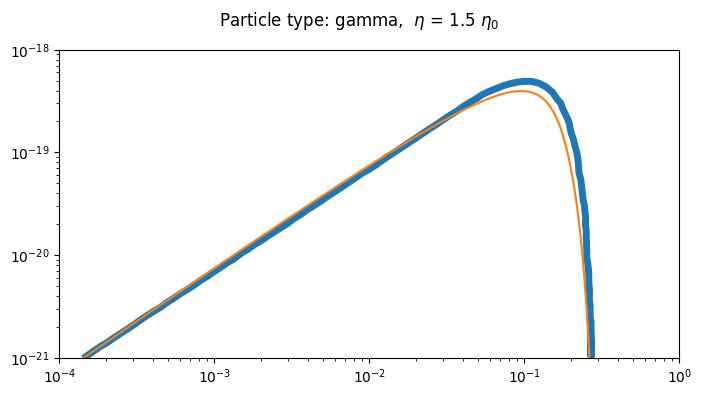

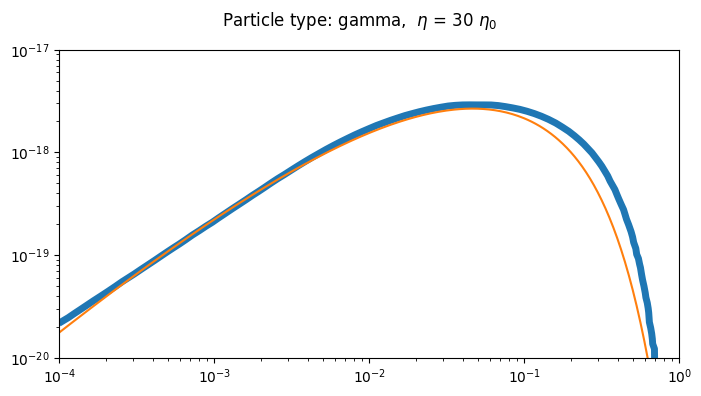

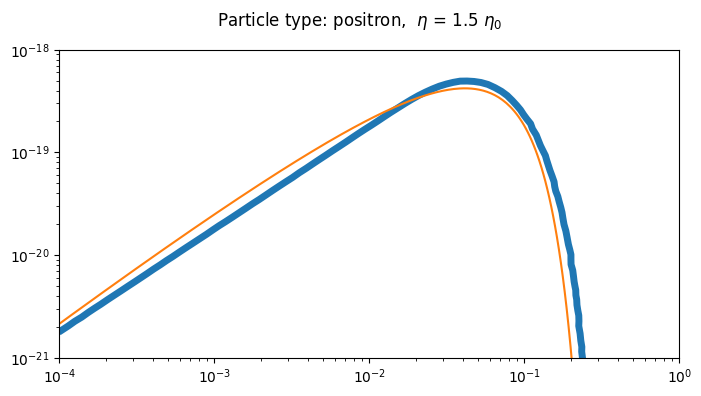

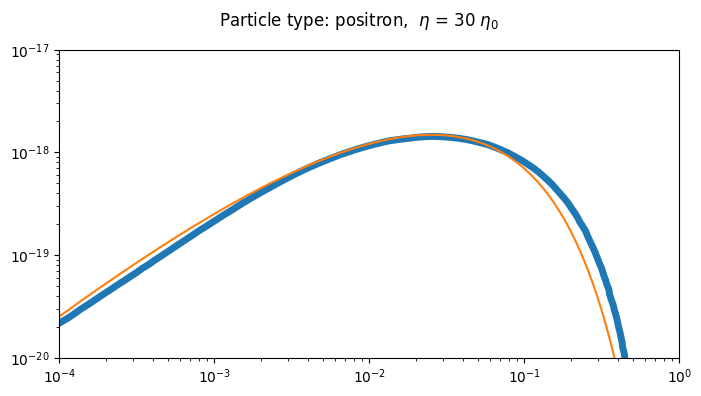

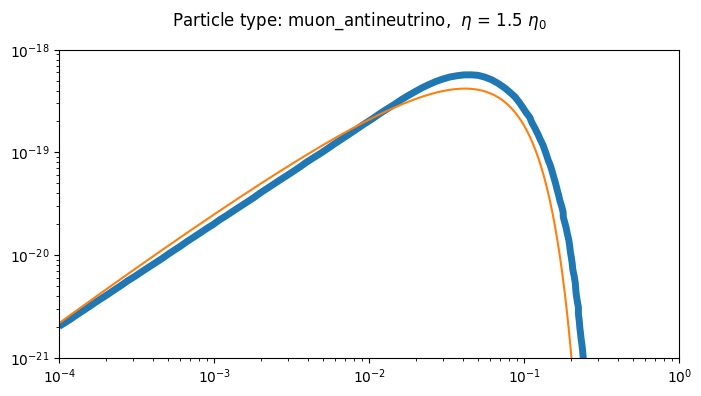

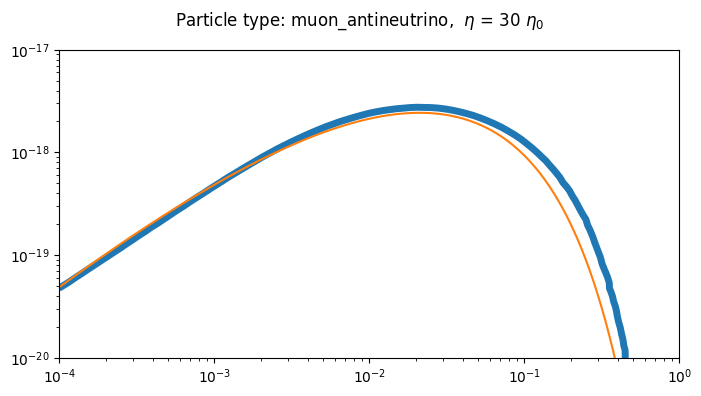

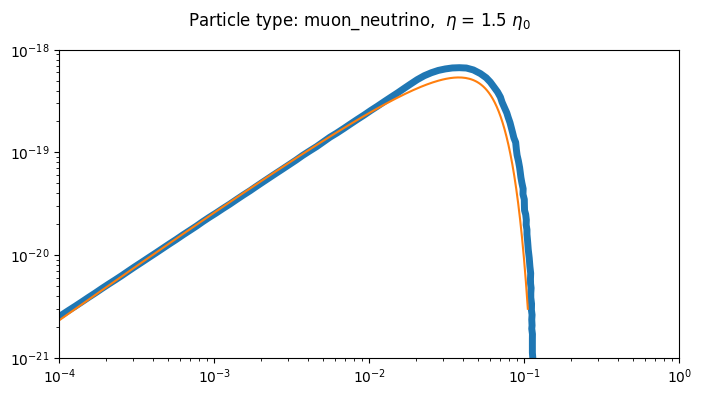

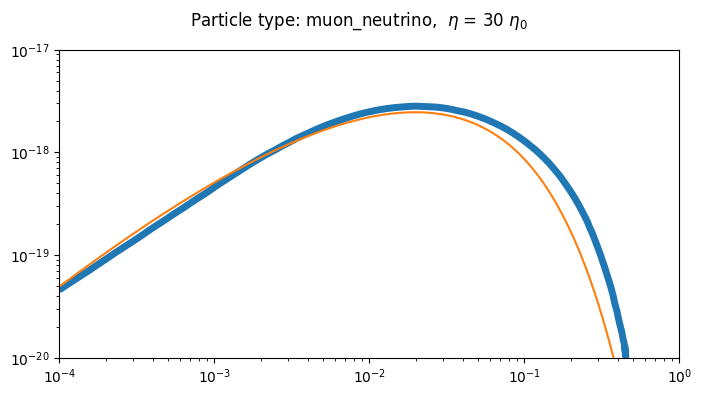

In [10]:
particle_types_Phi = ["gamma","positron","muon_antineutrino","muon_neutrino"]
# particle_types_Phi = ["gamma"]

for particle in particle_types_Phi:
    plot_Phi(particle,1.5)
    plot_Phi(particle,30)